<a href="https://colab.research.google.com/github/bornee09/kickboard_research/blob/main/microbit_circular_motion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔄 마이크로비트 원운동 데이터 분석

마이크로비트의 **가속도 센서(+ 지자기 센서)** 로 측정한 원운동 데이터를 분석하는 노트북입니다.

**이 노트북에서 하는 일**
1. 데이터 불러오기 · 정리 (균일 간격 재샘플링, 단위 변환)
2. 노이즈 제거 (저역통과 필터)
3. 주파수 분석(FFT) → **주기 T, 각속도 ω**
4. 회전각 θ(t), 순간 각속도 ω(t) 구하기
5. 구심가속도 $a_c$ 구하기 → **반지름 $r = a_c/\omega^2$**, 선속도 $v=\omega r$
6. 여러 속도 구간에서 $a_c \propto \omega^2$ 관계 검증

> 데이터 파일이 없으면 **가상의 샘플 데이터**로 자동 실행되므로, 먼저 끝까지 한 번 돌려 보며 흐름을 익힐 수 있어요.

---
## 📌 먼저 알아둘 점: 어떤 방식으로 돌렸나요?

센서가 어떻게 움직이느냐에 따라 **가속도 신호의 모양이 완전히 달라집니다.**

| 모드 | 상황 | 가속도 신호 | 주파수는 어디서? |
|---|---|---|---|
| `"rotating"` | 마이크로비트를 **회전판/줄 끝에 고정**해 함께 회전 (방향도 같이 돈다) | 센서 기준으로 구심가속도 방향이 항상 같음 → ax, ay가 **거의 일정** | **지자기 센서(mx, my)** 가 회전하며 사인 파형 |
| `"fixed"` | 방향은 그대로 두고 **손으로 원을 그리듯** 움직임 | ax, ay가 **사인파** (위상차 90°) | 가속도(ax, ay) |

- `rotating` 모드는 마이크로비트가 **수평면(바닥과 평행)** 에서 돈다고 가정합니다. (중력은 z축에만 걸림)
- 마이크로비트 V1/V2에는 자이로 센서가 없어서, 회전 속도는 지자기 센서로 구하는 것이 가장 간단합니다.

---
## 📡 데이터 수집 방법

### 마이크로비트 코드 (MicroPython, Mu 에디터)
```python
from microbit import *

accelerometer.set_range(8)      # ±8g (원운동은 가속도가 크므로 8g 권장)
# compass.calibrate()           # rotating 모드라면 시작 전에 한 번 보정하면 더 좋음

while True:
    t = running_time()                       # ms
    x, y, z = accelerometer.get_values()     # mg 단위
    mx, my, mz = compass.get_x(), compass.get_y(), compass.get_z()
    print("{},{},{},{},{},{},{}".format(t, x, y, z, mx, my, mz))
    sleep(10)                                # 약 100 Hz
```

### 저장하는 법
- **Mu 에디터**: 시리얼 출력(REPL)을 복사해서 `microbit_data.csv` 로 저장하고, 맨 윗줄에 `t_ms,ax,ay,az,mx,my,mz` 를 추가
- 또는 아래의 `record_from_serial()` 함수로 PC에서 바로 기록 (pyserial 필요)
- 첫 줄(헤더)이 없어도 됩니다. 열 순서만 `t_ms, ax, ay, az, mx, my, mz` 이면 OK (mx~mz는 없어도 됨).

> ⚠️ 마이크로비트 가속도 값은 **mg(1/1000 g)** 단위입니다. 아래에서 m/s²로 변환합니다.

## 1. 설정

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, savgol_filter

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "axes.unicode_minus": False})

# ===================== ✏️ 여기만 수정하세요 =====================
DATA_FILE   = "microbit-data-circle-sample.csv"   # 측정 데이터 파일 (없으면 샘플 데이터 사용)
COLUMN_MAP  = {"VAL_A": "ax", "VAL_B": "ay", "VAL_C": "az"}   # 파일의 열 이름 -> 축 이름 (⚠️ 실제 대응을 확인하세요)
CLIP_MG     = None                  # 센서 포화값. None이면 자동 감지 (±2g 설정이면 약 2040)
AUTO_TRIM_CLIP = True               # True: 포화된 구간을 지나 마지막 포화 직후부터 분석
PLANE_AXES  = ("ax", "ay")          # 회전 평면에 해당하는 두 축 (rotating 모드의 a_c 계산용)
MOTION_MODE = "rotating"            # "rotating" (센서가 같이 회전) 또는 "fixed" (방향 고정, 원을 그리며 이동)
RADIUS_M    = None                  # 실측한 회전 반지름 (m). 모르면 None
T_START, T_END = None, None         # 분석할 시간 구간(초). 전체를 쓰려면 None

LOWPASS_HZ  = 12.0                  # 저역통과 필터 차단 주파수 (Hz)
EDGE_S      = 0.5                   # 필터 가장자리 왜곡을 피하려고 앞뒤로 버릴 시간 (초)
WIN_S, STEP_S = 2.0, 0.5            # 구간별 분석 창 길이/이동 간격 (초)
# ==============================================================

G = 9.80665
COLS = ["t_ms", "ax", "ay", "az", "mx", "my", "mz"]

## 2. 데이터 불러오기

파일이 있으면 읽고, 없으면 **샘플 데이터**(반지름 0.30 m, 각속도 5 → 11 rad/s로 점점 빨라짐)를 생성합니다.

In [2]:
def make_sample(mode="rotating", T=15.0, fs=100, r=0.30, seed=0):
    """가상의 마이크로비트 원운동 데이터 (속도가 점점 증가)"""
    rng = np.random.default_rng(seed)
    n = int(T * fs)
    t_ms = np.cumsum(rng.choice([10, 10, 10, 11, 9], size=n))
    t = t_ms / 1000
    omega = 5.0 + 0.4 * t                                        # rad/s
    theta = np.concatenate([[0], np.cumsum(0.5 * (omega[1:] + omega[:-1]) * np.diff(t))])
    alpha = np.gradient(omega, t)

    if mode == "rotating":                                       # 센서가 같이 회전
        ax = -omega**2 * r / G * 1000                            # 구심가속도 (mg)
        ay = r * alpha / G * 1000                                # 접선가속도(작음)
        mx = 35000 * np.cos(theta) + 4000                        # 지자기: 회전하며 사인파
        my = -35000 * np.sin(theta) - 2500
    else:                                                        # 방향 고정, 원을 그리며 이동
        ax = -omega**2 * r * np.cos(theta) / G * 1000 + 40
        ay = -omega**2 * r * np.sin(theta) / G * 1000 - 25
        mx = np.full(n, 4000.0); my = np.full(n, -2500.0)

    noise = lambda s: rng.normal(0, s, n)
    return pd.DataFrame({
        "t_ms": t_ms,
        "ax": np.round(ax + noise(15)), "ay": np.round(ay + noise(15)),
        "az": np.round(-1000 + noise(15)),
        "mx": np.round(mx + noise(500)), "my": np.round(my + noise(500)),
        "mz": np.round(-20000 + noise(500)),
    })


def _clean(tc, vc):
    """NaN 제거, 시간순 정렬, 시간이 증가하지 않는 점 제거"""
    tc, vc = np.asarray(tc, float), np.asarray(vc, float)
    ok = ~(np.isnan(tc) | np.isnan(vc))
    tc, vc = tc[ok], vc[ok]
    o = np.argsort(tc, kind="stable"); tc, vc = tc[o], vc[o]
    keep = np.concatenate([[True], np.diff(tc) > 0])
    return tc[keep], vc[keep]

def df_to_raw(df):
    """t_ms, ax, ay, ... 형식 -> {채널: (시간[s], 값)}"""
    return {c: _clean(df["t_ms"] / 1000, pd.to_numeric(df[c], errors="coerce"))
            for c in COLS[1:] if c in df.columns}

def load_microbit_file(path):
    """다음 형식을 자동 인식합니다.
       (a) t_ms,ax,ay,az,mx,my,mz  (콤마 CSV)
       (b) 'sep=\\t' 첫 줄 + 탭 구분 + 채널마다 time 열이 있는 형식 (time, VAL_A, time, VAL_B, ...)"""
    with open(path, encoding="utf-8-sig") as fh:
        first = fh.readline().rstrip("\r\n")
    sep, skip = None, 0
    if first.lower().startswith("sep="):
        sep, skip = (first[4:].replace("\\t", "\t") or ","), 1
    df = pd.read_csv(path, sep=sep, engine="python", skiprows=skip, encoding="utf-8-sig")

    if "t_ms" in df.columns:                                         # (a)
        return df_to_raw(df)
    if df.shape[1] >= 2 and not any("time" in str(c).lower() for c in df.columns):
        df = pd.read_csv(path, sep=sep, engine="python", skiprows=skip, header=None,
                         names=COLS[:df.shape[1]], encoding="utf-8-sig")
        return df_to_raw(df)

    raw, last_t, k = {}, None, 0                                     # (b)
    for col in df.columns:
        if "time" in str(col).lower():
            last_t = pd.to_numeric(df[col], errors="coerce")
        else:
            name = COLUMN_MAP.get(str(col).strip(), COLS[1 + k]); k += 1
            raw[name] = _clean(last_t, pd.to_numeric(df[col], errors="coerce"))
    # 시간 단위 자동 판별 (간격 중앙값이 0.5보다 크면 ms로 간주)
    med_dt = np.median(np.diff(next(iter(raw.values()))[0]))
    if med_dt > 0.5:
        raw = {c: (tc / 1000, vc) for c, (tc, vc) in raw.items()}
    return raw


if os.path.exists(DATA_FILE):
    raw = load_microbit_file(DATA_FILE)
    print(f"✅ 파일 사용: {DATA_FILE}")
    USING_SAMPLE = False
else:
    raw = df_to_raw(make_sample(MOTION_MODE))
    print(f"ℹ️ '{DATA_FILE}' 파일이 없어 샘플 데이터({MOTION_MODE} 모드)를 사용합니다.")
    USING_SAMPLE = True

print("불러온 채널:", {c: f"{len(v[0])}점, {v[0][0]:.2f}~{v[0][-1]:.2f} s" for c, v in raw.items()})
pd.DataFrame({c: pd.Series(v[1]) for c, v in raw.items()}).head()

✅ 파일 사용: microbit-data-circle-sample.csv
불러온 채널: {'ax': '1228점, 0.00~10.50 s', 'ay': '1227점, 0.00~10.49 s', 'az': '1226점, 0.00~10.49 s'}


,ax,ay,az
0,1620.0,2040.0,1316.0
1,1644.0,2040.0,1316.0
2,1644.0,2040.0,1316.0
3,1644.0,2040.0,1284.0
4,1624.0,2040.0,1284.0


## 3. 전처리

1. 숫자가 아닌 줄/중복 시간 제거  
2. 마이크로비트는 샘플링 간격이 조금씩 흔들리므로 **일정한 간격으로 재샘플링**  
3. 가속도 **mg → m/s²** 변환

In [3]:
# --- 균일 간격 시간축 (채널마다 시간축이 약간 달라도 각자 보간) ---
t_start = max(v[0][0] for v in raw.values())
t_stop  = min(v[0][-1] for v in raw.values())
dts = np.concatenate([np.diff(v[0]) for v in raw.values()])
fs = int(round(1 / np.median(dts)))
t = np.arange(0, t_stop - t_start, 1 / fs)
S = {c: np.interp(t + t_start, tc, vc) for c, (tc, vc) in raw.items()}
print(f"측정 시간: {t[-1]:.1f} s,  샘플링 주파수 ≈ {fs} Hz  (간격 표준편차 {dts.std()*1000:.2f} ms)")

# 센서 갱신 빈도: 값이 실제로 바뀐 비율 (마이크로비트 센서는 로깅 속도보다 느리게 갱신될 수 있음)
chg = np.mean([np.mean(np.diff(vc) != 0) for c, (tc, vc) in raw.items() if c in ("ax", "ay", "az")])
print(f"값이 바뀐 샘플 비율 {chg*100:.0f}%  →  실효 센서 갱신 ≈ {fs*chg:.0f} Hz")

# --- 포화(clipping) 검사: 마이크로비트 가속도 센서는 설정 범위(±2g/4g/8g)를 넘으면 값이 잘립니다 ---
acc = [c for c in ("ax", "ay", "az") if c in S]
clip_level = CLIP_MG or max(np.max(np.abs(S[c])) for c in acc)
clipped = np.zeros_like(t, bool)
for c in acc:
    m = np.abs(S[c]) >= clip_level - 1
    if m.sum() >= 5:
        print(f"⚠️ {c}: 포화값({clip_level:.0f}) 샘플 {m.sum()}개 ({m.mean()*100:.0f}%)  — 실제 가속도는 이보다 큽니다")
        clipped |= m
if clipped.any():
    last_clip = t[np.where(clipped)[0][-1]]
    print(f"   마지막 포화 시각: {last_clip:.2f} s")
else:
    last_clip = None

# 단위 변환: mg -> m/s^2  (포화 판정이 끝난 뒤에 변환)
for c in acc:
    S[c] = S[c] * G / 1000

HAS_MAG = all(c in S and S[c].std() > 0 for c in ("mx", "my"))

# 분석 구간 선택
keep = np.ones_like(t, bool)
if T_START is not None: keep &= t >= T_START
if T_END   is not None: keep &= t <= T_END
if AUTO_TRIM_CLIP and last_clip is not None:
    keep &= t >= last_clip + 0.3
    print(f"   → 포화 이후 {last_clip+0.3:.2f} s 부터 분석합니다 (AUTO_TRIM_CLIP=False로 끌 수 있음)")
t_full, S_full, clipped_full = t, dict(S), clipped          # 원본 전체(그래프용)
t = t[keep]; S = {c: v[keep] for c, v in S.items()}; clipped = clipped[keep]
print("사용 채널:", list(S), "| 지자기 센서 사용 가능:", HAS_MAG)

측정 시간: 10.5 s,  샘플링 주파수 ≈ 125 Hz  (간격 표준편차 6.73 ms)
값이 바뀐 샘플 비율 29%  →  실효 센서 갱신 ≈ 36 Hz
⚠️ ax: 포화값(2040) 샘플 110개 (8%)  — 실제 가속도는 이보다 큽니다
⚠️ ay: 포화값(2040) 샘플 339개 (26%)  — 실제 가속도는 이보다 큽니다
   마지막 포화 시각: 2.73 s
   → 포화 이후 3.03 s 부터 분석합니다 (AUTO_TRIM_CLIP=False로 끌 수 있음)
사용 채널: ['ax', 'ay', 'az'] | 지자기 센서 사용 가능: False


### 원시 데이터 확인

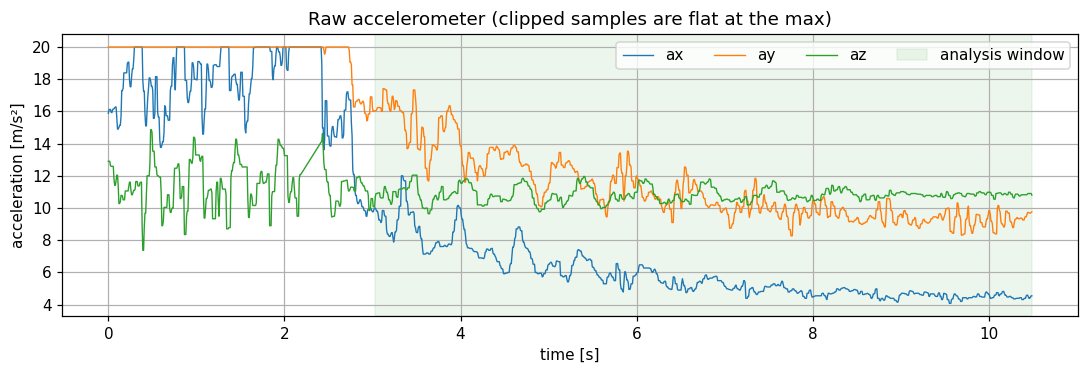

In [4]:
fig, axes = plt.subplots(2 if HAS_MAG else 1, 1, figsize=(10, 6 if HAS_MAG else 3.5), sharex=True)
axes = np.atleast_1d(axes)
for c in ("ax", "ay", "az"):
    axes[0].plot(t_full, S_full[c], label=c, lw=0.9)
axes[0].axvspan(t[0], t[-1], color="g", alpha=0.07, label="analysis window")
axes[0].set(ylabel="acceleration [m/s²]", title="Raw accelerometer (clipped samples are flat at the max)"); axes[0].legend(ncol=4)
if HAS_MAG:
    for c in ("mx", "my"):
        axes[1].plot(t_full, S_full[c], label=c, lw=0.9)
    axes[1].set(ylabel="magnetometer [raw]", xlabel="time [s]", title="Raw magnetometer"); axes[1].legend(ncol=2)
else:
    axes[0].set_xlabel("time [s]")
plt.tight_layout(); plt.show()

## 4. 노이즈 제거 (저역통과 필터)

원운동 신호는 낮은 주파수(수 Hz)이므로, 그 위의 센서 잡음은 **Butterworth 저역통과 필터**로 제거합니다.  
`filtfilt` 는 앞뒤로 두 번 필터링해서 **위상 지연이 없습니다.**

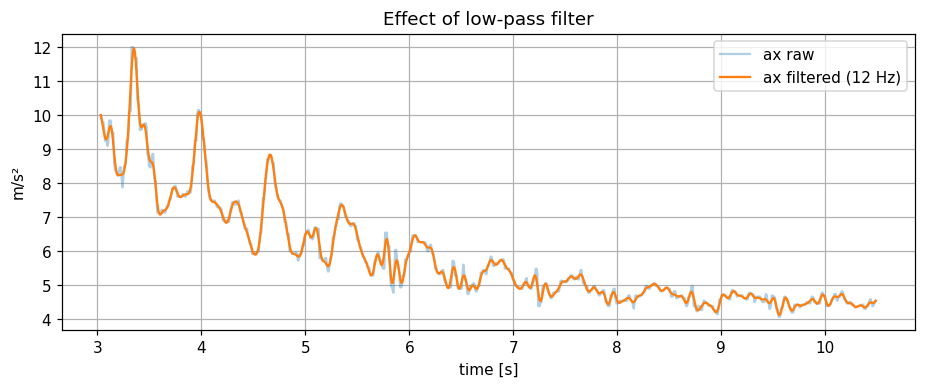

In [5]:
def lowpass(x, fc, fs, order=4):
    b, a = butter(order, fc / (fs / 2), btype="low")
    return filtfilt(b, a, x)

fc = min(LOWPASS_HZ, 0.4 * fs)
F = {c: lowpass(v, fc, fs) for c, v in S.items()}

valid = (t > t[0] + EDGE_S) & (t < t[-1] - EDGE_S)     # 가장자리 제외 마스크

fig, ax_ = plt.subplots(figsize=(10, 3.5))
ax_.plot(t, S["ax"], alpha=0.35, label="ax raw"); ax_.plot(t, F["ax"], label=f"ax filtered ({fc:.0f} Hz)")
ax_.set(xlabel="time [s]", ylabel="m/s²", title="Effect of low-pass filter"); ax_.legend()
plt.show()

## 5. 주파수 분석 (FFT) → 주기 T, 각속도 ω

원운동을 하는 동안 **회전각에 따라 사인 파형으로 변하는 신호**의 주파수가 곧 회전 주파수입니다.

- `rotating` 모드 → 지자기 센서 (mx, my)
- `fixed` 모드 → 가속도 센서 (ax, ay)

ℹ️ rotating 모드인데 지자기 데이터가 없습니다. 가속도 신호에 남은 진동 성분(기울기에 따른 중력 성분, 진동 등)으로 주파수를 추정합니다.
주파수 분석에 사용하는 채널: ('ax', 'ay')
FFT 피크 주파수 f = 1.373 Hz  →  주기 T = 0.728 s,  ω = 2πf = 8.63 rad/s


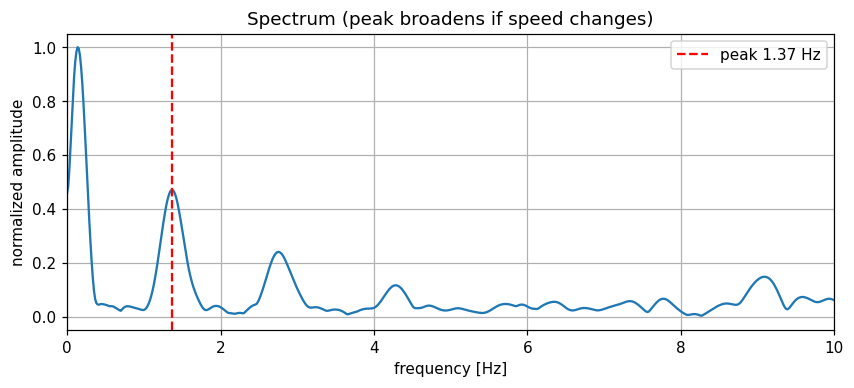

In [6]:
if MOTION_MODE == "rotating" and HAS_MAG:
    CH = ("mx", "my")
else:
    CH = ("ax", "ay")
    if MOTION_MODE == "rotating":
        print("ℹ️ rotating 모드인데 지자기 데이터가 없습니다. 가속도 신호에 남은 진동 성분(기울기에 따른 중력 성분, 진동 등)으로 주파수를 추정합니다.")
print("주파수 분석에 사용하는 채널:", CH)

def spectrum(sig, fs, pad=8):
    sig = sig[valid] - sig[valid].mean()
    n = len(sig)
    nfft = 2 ** int(np.ceil(np.log2(n * pad)))
    sp = np.abs(np.fft.rfft(sig * np.hanning(n), nfft))
    return np.fft.rfftfreq(nfft, 1 / fs), sp

f, sp1 = spectrum(F[CH[0]], fs)
_, sp2 = spectrum(F[CH[1]], fs)
sp = sp1 / sp1.max() + sp2 / sp2.max()

band = (f >= 0.3) & (f <= fc)
f_fft = f[band][np.argmax(sp[band])]
print(f"FFT 피크 주파수 f = {f_fft:.3f} Hz  →  주기 T = {1/f_fft:.3f} s,  ω = 2πf = {2*np.pi*f_fft:.2f} rad/s")

plt.figure(figsize=(9, 3.5))
plt.plot(f, sp / sp.max()); plt.axvline(f_fft, color="r", ls="--", label=f"peak {f_fft:.2f} Hz")
plt.xlim(0, min(10, fc)); plt.xlabel("frequency [Hz]"); plt.ylabel("normalized amplitude")
plt.title("Spectrum (peak broadens if speed changes)"); plt.legend(); plt.show()

> 💡 회전 속도가 **시간에 따라 변하면** 피크가 퍼져 보이고 FFT는 평균적인 값만 알려줍니다. 아래에서 각도를 직접 추적해 **순간 각속도 ω(t)** 를 구합니다.

### 5-2. 시간–주파수 분석 (속도가 변할 때)

짧은 시간 창으로 FFT를 반복(STFT)해서, **시간에 따른 지배 주파수(릿지)** 를 따라갑니다.
회전이 점점 느려지는 측정에서는 이 결과가 곧 f(t), ω(t) = 2πf(t) 입니다.

사용 채널: ['ax', 'ay', 'az']
릿지 주파수: 1.43 Hz (시작) → 1.16 Hz (끝),  범위 1.16 ~ 1.43 Hz


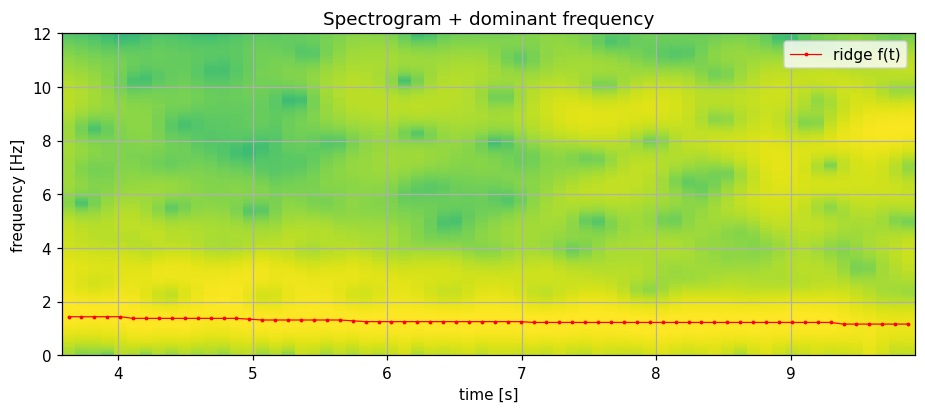

In [7]:
from scipy.signal import detrend, medfilt

RIDGE_CH = list(CH) if (MOTION_MODE == "rotating" and HAS_MAG) else [c for c in ("ax", "ay", "az") if c in F]

def track_ridge(P, fr, band, penalty_db_per_hz=8.0):
    """주파수가 갑자기 튀지 않도록 연속성을 주는 릿지 추적 (Viterbi). 노이즈 피크로 건너뛰는 것을 막아 줍니다."""
    f = fr[band]
    L = 10 * np.log10(P[band] + 1e-12)                               # (주파수, 시간) dB
    cost = penalty_db_per_hz * np.abs(f[:, None] - f[None, :])       # 주파수 이동 벌점
    score = L[:, 0].copy(); back = np.zeros(L.shape, int)
    for j in range(1, L.shape[1]):
        tot = score[None, :] - cost                                  # [현재, 이전]
        back[:, j] = np.argmax(tot, axis=1)
        score = L[:, j] + tot[np.arange(len(f)), back[:, j]]
    path = np.zeros(L.shape[1], int); path[-1] = np.argmax(score)
    for j in range(L.shape[1] - 1, 0, -1):
        path[j - 1] = back[path[j], j]
    return f[path]

def stft_ridge(chs, fs, win_s=1.2, step_s=0.1, fmin=0.5, fmax=None, nfft=4096):
    nper, step = int(win_s * fs), max(1, int(step_s * fs))
    fr = np.fft.rfftfreq(nfft, 1 / fs)
    band = (fr >= fmin) & (fr <= (fmax or fc))
    tt, P = [], []
    for i0 in range(0, len(chs[0]) - nper + 1, step):
        p = np.zeros(len(fr))
        for x in chs:
            sp = np.abs(np.fft.rfft(detrend(x[i0:i0 + nper]) * np.hanning(nper), nfft)) ** 2
            p += sp / (sp[band].max() + 1e-12)          # 채널별로 정규화해서 더함
        tt.append(t[i0 + nper // 2]); P.append(p)
    P = np.array(P).T
    return np.array(tt), fr, P, track_ridge(P, fr, band)

t_r, f_r, P_r, ridge = stft_ridge([F[c] for c in RIDGE_CH], fs)
ridge_t = np.interp(t, t_r, ridge)                     # 원래 시간축으로 보간

print("사용 채널:", RIDGE_CH)
print(f"릿지 주파수: {ridge[0]:.2f} Hz (시작) → {ridge[-1]:.2f} Hz (끝),  범위 {ridge.min():.2f} ~ {ridge.max():.2f} Hz")

plt.figure(figsize=(10, 3.8))
plt.pcolormesh(t_r, f_r, 10 * np.log10(P_r + 1e-9), shading="auto", cmap="viridis")
plt.plot(t_r, ridge, "r.-", ms=3, lw=0.8, label="ridge f(t)")
plt.ylim(0, min(12, fc)); plt.xlabel("time [s]"); plt.ylabel("frequency [Hz]")
plt.title("Spectrogram + dominant frequency"); plt.legend(); plt.show()

## 6. 회전각 θ(t)와 각속도 ω(t)

두 채널을 각각 **−1 ~ +1** 로 정규화(중심 이동 + 크기 보정)하면 원 위의 점이 되고,
$\theta=\mathrm{atan2}(y,x)$ 를 `unwrap` 하면 누적 회전각을 얻습니다. θ를 시간에 대해 미분하면 ω입니다.

각도 추정 방식: ridge
분석 구간 회전수 ≈ 8.2 바퀴
평균 각속도 ω ≈ 7.98 rad/s  (FFT: 8.63 rad/s)


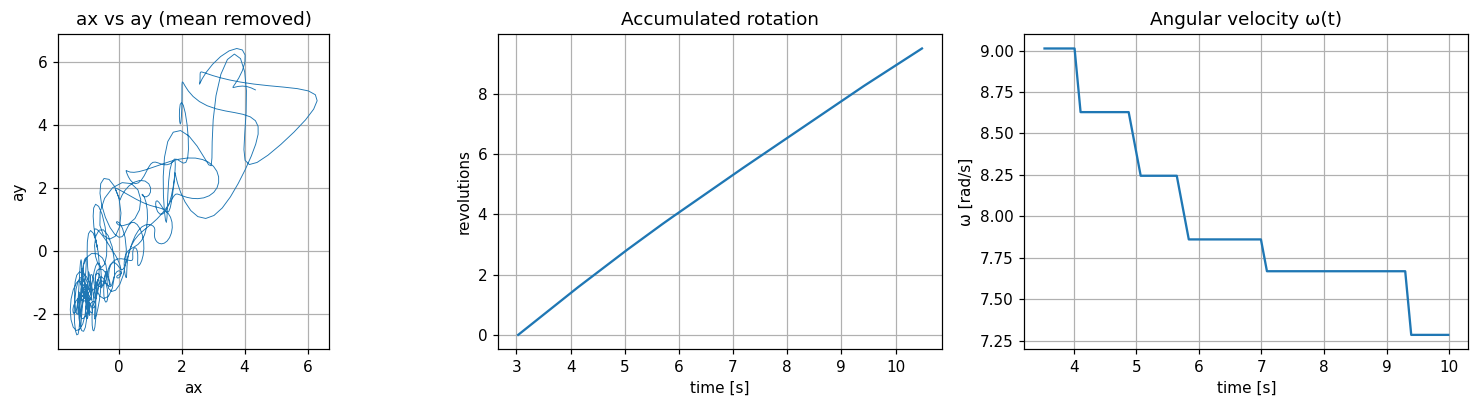

In [8]:
def normalize(x):
    lo, hi = np.percentile(x[valid], [5, 95])
    return (x - (hi + lo) / 2) / ((hi - lo) / 2)

# 각도를 어떻게 구할까?
#  - quadrature: 사인/코사인 위상차를 가진 두 채널(지자기 mx,my 또는 fixed 모드의 ax,ay)이 있을 때 -> atan2로 직접
#  - ridge     : 그런 두 채널이 없을 때(가속도만 있는 rotating) -> 스펙트로그램 릿지 f(t)를 적분
ANGLE_SOURCE = "ridge" if (MOTION_MODE == "rotating" and not HAS_MAG) else "quadrature"
print("각도 추정 방식:", ANGLE_SOURCE)

if ANGLE_SOURCE == "quadrature":
    u, v = normalize(F[CH[0]]), normalize(F[CH[1]])
    theta = np.unwrap(np.arctan2(v, u))
    if theta[-1] < theta[0]:                       # 회전 방향이 반대면 부호를 맞춤 (부호는 센서 배치에 따라 임의)
        theta = -theta
    w = int(0.3 * fs) // 2 * 2 + 1                 # Savitzky-Golay 창 (홀수)
    omega = np.abs(savgol_filter(theta, w, 3, deriv=1, delta=1 / fs))
else:
    u, v = F["ax"] - F["ax"][valid].mean(), F["ay"] - F["ay"][valid].mean()
    omega = 2 * np.pi * ridge_t
    theta = np.concatenate([[0], np.cumsum(0.5 * (omega[1:] + omega[:-1]) * np.diff(t))])

n_rev = (theta[valid][-1] - theta[valid][0]) / (2 * np.pi)
print(f"분석 구간 회전수 ≈ {n_rev:.1f} 바퀴")
print(f"평균 각속도 ω ≈ {omega[valid].mean():.2f} rad/s  (FFT: {2*np.pi*f_fft:.2f} rad/s)")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(u, v, lw=0.6); axes[0].set_aspect("equal")
axes[0].set(title=("Normalized " + CH[0] + " vs " + CH[1]) if ANGLE_SOURCE == "quadrature" else "ax vs ay (mean removed)",
            xlabel=CH[0] if ANGLE_SOURCE == "quadrature" else "ax", ylabel=CH[1] if ANGLE_SOURCE == "quadrature" else "ay")
axes[1].plot(t, theta / (2 * np.pi)); axes[1].set(title="Accumulated rotation", xlabel="time [s]", ylabel="revolutions")
axes[2].plot(t[valid], omega[valid]); axes[2].set(title="Angular velocity ω(t)", xlabel="time [s]", ylabel="ω [rad/s]")
plt.tight_layout(); plt.show()

## 7. 구심가속도 $a_c$ 와 반지름 추정

- `rotating`: 수평면 가속도의 크기 $a_c=\sqrt{a_x^2+a_y^2}$ (중력은 z축에만 작용)
- `fixed`: (ax, ay)가 그리는 **원의 반지름**이 $a_c$ → 원의 중심 이동량은 센서 영점 오차(오프셋)

구심가속도 관계식 $a_c=\omega^2 r$ 에서

$$ r = \frac{a_c}{\omega^2}, \qquad v = \omega r $$

평균 구심가속도 a_c = 12.33 m/s²  (1.26 g)
추정 반지름 r = a_c/ω² (중앙값) = 19.2 cm
선속도 v = ωr : 1.40 ~ 1.73 m/s


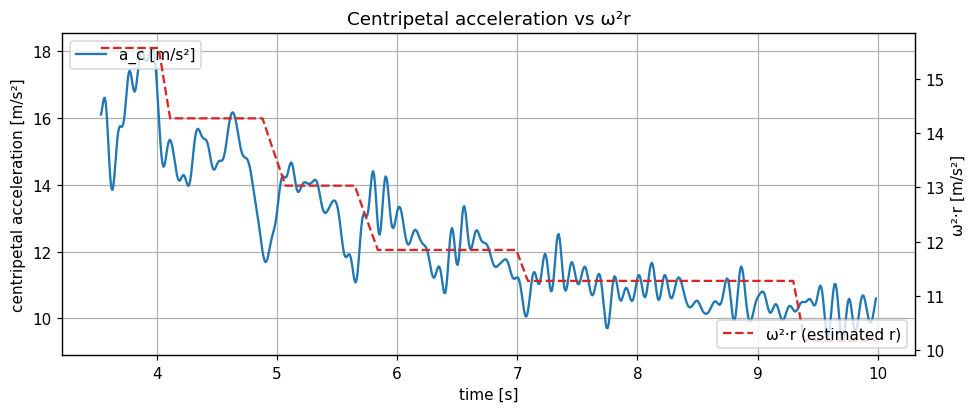

In [9]:
def fit_circle(x, y):
    """최소제곱 원 맞춤 (Kåsa 방법) -> 중심(cx, cy), 반지름"""
    A = np.c_[2 * x, 2 * y, np.ones_like(x)]
    c, *_ = np.linalg.lstsq(A, x**2 + y**2, rcond=None)
    return c[0], c[1], np.sqrt(c[2] + c[0]**2 + c[1]**2)

if MOTION_MODE == "fixed":
    cx, cy, R = fit_circle(F["ax"][valid], F["ay"][valid])
    print(f"(ax, ay) 원 맞춤: 중심 = ({cx:.3f}, {cy:.3f}) m/s² (영점 오프셋), 반지름 = {R:.2f} m/s²")
    a_c = np.hypot(F["ax"] - cx, F["ay"] - cy)
else:
    a_c = np.hypot(F[PLANE_AXES[0]], F[PLANE_AXES[1]])

a_tot = np.sqrt(F["ax"]**2 + F["ay"]**2 + F["az"]**2)

r_pt = a_c[valid] / omega[valid]**2                  # 순간값으로 구한 반지름
r_est = np.median(r_pt)
v_est = omega[valid] * r_est

print(f"평균 구심가속도 a_c = {a_c[valid].mean():.2f} m/s²  ({a_c[valid].mean()/G:.2f} g)")
print(f"추정 반지름 r = a_c/ω² (중앙값) = {r_est*100:.1f} cm")
print(f"선속도 v = ωr : {v_est.min():.2f} ~ {v_est.max():.2f} m/s")
if RADIUS_M:
    print(f"실측 반지름 = {RADIUS_M*100:.1f} cm  →  오차 {abs(r_est-RADIUS_M)/RADIUS_M*100:.1f} %")

fig, ax1 = plt.subplots(figsize=(10, 3.8))
ax1.plot(t[valid], a_c[valid], color="C0", label="a_c [m/s²]")
ax1.set(xlabel="time [s]", ylabel="centripetal acceleration [m/s²]")
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(t[valid], omega[valid]**2 * r_est, "C3--", label="ω²·r (estimated r)")
ax2.set_ylabel("ω²·r [m/s²]")
ax1.legend(loc="upper left"); ax2.legend(loc="lower right"); plt.title("Centripetal acceleration vs ω²r")
plt.show()

## 8. $a_c \propto \omega^2$ 관계 검증

회전 속도를 바꿔 가며 돌렸다면(점점 빠르게, 또는 몇 단계로), 시간 창을 옮겨 가며 **(ω, a_c) 쌍**을 만들고
$a_c = r\,\omega^2$ 의 기울기로 반지름을 구합니다. 로그-로그 기울기가 **2** 에 가까우면 이론과 일치합니다.

In [10]:
rows = []
for t0 in np.arange(t[0] + EDGE_S, t[-1] - EDGE_S - WIN_S, STEP_S):
    m = (t >= t0) & (t < t0 + WIN_S)
    slope = np.polyfit(t[m], theta[m], 1)[0]
    rows.append((t0 + WIN_S / 2, abs(slope), a_c[m].mean()))
win = pd.DataFrame(rows, columns=["t_mid", "omega", "a_c"])

if len(win) < 4 or win["omega"].std() / win["omega"].mean() < 0.05:
    print("⚠️ 회전 속도 변화가 거의 없어 관계 검증이 어렵습니다. 속도를 바꿔 가며 다시 측정해 보세요.")
else:
    w2 = win["omega"]**2
    r_fit = (win["a_c"] * w2).sum() / (w2**2).sum()              # 원점을 지나는 직선 a = r ω²
    pred = r_fit * w2
    r2 = 1 - ((win["a_c"] - pred)**2).sum() / ((win["a_c"] - win["a_c"].mean())**2).sum()
    expo = np.polyfit(np.log(win["omega"]), np.log(win["a_c"]), 1)[0]
    print(f"a_c = r·ω² 맞춤(원점 통과):  r = {r_fit*100:.1f} cm,  R² = {r2:.4f}")
    k, b0 = np.polyfit(w2, win["a_c"], 1)                          # a_c = r·ω² + b  (b: 영점 오차/중력 성분 등 상수 오프셋)
    r2b = 1 - ((win["a_c"] - (k * w2 + b0))**2).sum() / ((win["a_c"] - win["a_c"].mean())**2).sum()
    print(f"a_c = r·ω² + b 맞춤:       r = {k*100:.1f} cm,  b = {b0:.2f} m/s²,  R² = {r2b:.4f}   (b가 크면 오프셋이 섞였다는 뜻)")
    print(f"log-log 기울기(이론값 2) = {expo:.2f}")
    if RADIUS_M:
        print(f"실측 반지름 {RADIUS_M*100:.1f} cm 와의 오차: {abs(r_fit-RADIUS_M)/RADIUS_M*100:.1f} %")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(w2, win["a_c"], s=18, label="windows")
    xs = np.linspace(0, w2.max() * 1.05, 50)
    axes[0].plot(xs, r_fit * xs, "r", label=f"through origin: r = {r_fit*100:.1f} cm (R²={r2:.3f})")
    axes[0].plot(xs, k * xs + b0, "g--", label=f"with offset: r = {k*100:.1f} cm, b = {b0:.1f}")
    axes[0].set(xlabel="ω² [rad²/s²]", ylabel="a_c [m/s²]", title="a_c vs ω²"); axes[0].legend()
    axes[1].loglog(win["omega"], win["a_c"], "o", ms=4)
    axes[1].loglog(win["omega"], r_fit * win["omega"]**2, "r-", label="slope = 2 (theory)")
    axes[1].set(xlabel="ω [rad/s]", ylabel="a_c [m/s²]", title=f"log-log (fitted slope {expo:.2f})"); axes[1].legend()
    plt.tight_layout(); plt.show()

⚠️ 회전 속도 변화가 거의 없어 관계 검증이 어렵습니다. 속도를 바꿔 가며 다시 측정해 보세요.


## 9. 결과 요약 및 저장

In [11]:
summary = pd.DataFrame({
    "항목": ["측정 시간 [s]", "샘플링 [Hz]", "회전수 [바퀴]", "평균 주파수 f [Hz]", "평균 주기 T [s]",
            "평균 각속도 ω [rad/s]", "평균 구심가속도 a_c [m/s²]", "추정 반지름 r [cm]", "선속도 v (평균) [m/s]"],
    "값": [round(t[-1] - t[0], 2), fs, round(n_rev, 2), round(f_fft, 3), round(1 / f_fft, 3),
          round(omega[valid].mean(), 2), round(a_c[valid].mean(), 2), round(r_est * 100, 1),
          round(v_est.mean(), 2)],
})
display(summary)

out = pd.DataFrame({"t_s": t, "theta_rad": theta, "omega_rad_s": omega, "a_c_m_s2": a_c, "a_total_m_s2": a_tot})
out.to_csv("circular_motion_result.csv", index=False)
print("💾 circular_motion_result.csv 저장 완료")

,항목,값
0,측정 시간 [s],7.460
1,샘플링 [Hz],125.000
2,회전수 [바퀴],8.190
3,평균 주파수 f [Hz],1.373
4,평균 주기 T [s],0.728
5,평균 각속도 ω [rad/s],7.980
6,평균 구심가속도 a_c [m/s²],12.330
7,추정 반지름 r [cm],19.200
8,선속도 v (평균) [m/s],1.530


💾 circular_motion_result.csv 저장 완료


## 🤔 생각해 볼 점

1. **`a_total` 은 왜 중력가속도(9.8)보다 클까요?** (`rotating` 모드에서 z축 중력과 구심가속도의 합성을 생각해 보세요)
2. 추정한 반지름과 **자로 잰 반지름**이 다르다면, 어떤 원인이 있을까요? (센서 칩 위치 ≠ 회전축 기준, 영점 오차, 판이 기울어짐, 필터 등)
3. 반지름을 고정하고 속도를 2배로 하면 구심가속도는 몇 배가 되나요? 데이터로 확인해 보세요.
4. 속도는 같게 하고 반지름을 바꾸면 $a_c = v^2/r$ 은 어떻게 변하나요?
5. 샘플링 주파수가 낮으면(예: 20 Hz) 빠른 회전에서 어떤 문제가 생길까요? (**나이퀴스트** 한계 생각해 보기)
6. ±2g 범위로 측정하면 어떤 일이 벌어질까요? (센서 포화 → 구심가속도가 잘림)

---
## 부록: PC에서 시리얼로 바로 기록하기 (선택)
`pip install pyserial` 후 사용하세요. 포트 이름은 Windows `COM3`, macOS `/dev/cu.usbmodem*`, Linux `/dev/ttyACM0` 처럼 환경마다 달라요.

In [12]:
def record_from_serial(port, seconds=20, out_csv="microbit_data.csv", baud=115200):
    """마이크로비트가 보내는 'ms,x,y,z,mx,my,mz' 줄을 seconds초 동안 받아 CSV로 저장"""
    import serial, time
    rows, t_end = [], time.time() + seconds
    with serial.Serial(port, baud, timeout=1) as ser:
        ser.reset_input_buffer()
        while time.time() < t_end:
            line = ser.readline().decode(errors="ignore").strip()
            if line.count(",") == 6:
                rows.append(line)
    with open(out_csv, "w") as fh:
        fh.write("t_ms,ax,ay,az,mx,my,mz\n" + "\n".join(rows))
    print(f"{len(rows)}줄 저장 → {out_csv}")

# record_from_serial("COM3", seconds=20)     # ← 사용 예 (주석 해제)